#  Modèles ARCH et GARCH avec la méthode de moments généralisés

* [pip install cvxopt]

In [1]:
#import cvxopt
from functools import partial
import math
import numpy as np
import scipy
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera

import matplotlib.pyplot as plt
#np.random.seed(777) #Jackpot

/Users/kebaiera/opt/anaconda3/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Simuler un GARCH(1, 1) 
La dynamique de la série temporelle est donnée par

\begin{align}
x_t &= \sigma_t \epsilon_t \quad \mbox{ avec } \epsilon \sim \mathcal{N}(0, 1) \mbox{ et}\\
\sigma_t^2 &= a_0+b_1 \sigma_{t-1}^2 + a_1 x_{t-1}^2 \\
\sigma_1 &= \sqrt{\frac{a_0}{1-a_1-b_1}} \\
\end{align}

Nos paramètres sont  $a_0 = 1$, $a_1=0.1$, and $b_1=0.8$. 
Nous laisserons tomber les premiers 10% de nos valeurs simulées (burn-in).

In [2]:
# Define parameters
a0 = 1.0
a1 = 0.1
b1 = 0.8
sigma1 = math.sqrt(a0 / (1 - a1 - b1))

print(list(range(1, 3)))

[1, 2]


In [3]:
np.random.seed(777) 
def simulate_GARCH(T, a0, a1, b1, sigma1):
    
    # Initialize our values
    X = np.ndarray(T)

    sigma = np.ndarray(T)
    sigma[0] = sigma1
   
    for t in range(1, T):
      
        X[t - 1] = sigma[t - 1] * np.random.normal(0, 1)

        sigma[t] = np.sqrt(a0 + b1 * sigma[t - 1]**2 + a1 * X[t - 1]**2)
        
    X[T - 1] = sigma[T - 1] * np.random.normal(0, 1)    
    
    return X, sigma

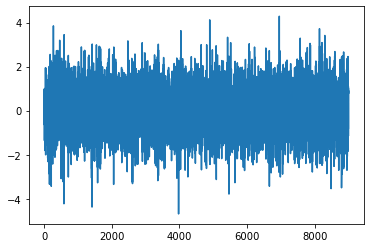

In [4]:
X, _ = simulate_GARCH(10000, a0, a1, b1, sigma1)
X = X[1000:] #  burn in
X = (X-np.mean(X)) / np.std(X) #  reduce X : Il faut réduire X

plt.plot(X)

Nous allons maintenant comparer les queues de distribution du processus GARCH (1, 1) avec celles d'une loi normale. Nous nous attendons à voir des queues plus grosses, car le processus GARCH (1, 1) aura plus souvent des valeurs extrêmes.

In [5]:
np.random.seed(777) 
def compare_tails_to_normal(X):
    # Define matrix to store comparisons
    A = np.zeros((2,4))
    for k in range(4):
        A[0, k] = len(X[X > (k + 1)]) / float(len(X)) # Estimate tails of X
        A[1, k] = 1 - stats.norm.cdf(k + 1) # Compare to Gaussian distribution
    return A

compare_tails_to_normal(X)

array([[1.56444444e-01, 2.40000000e-02, 2.00000000e-03, 2.22222222e-04],
       [1.58655254e-01, 2.27501319e-02, 1.34989803e-03, 3.16712418e-05]])

Sure enough, the tails of the GARCH(1, 1) process are fatter. We can also look at this graphically, although it's a little tricky to see.

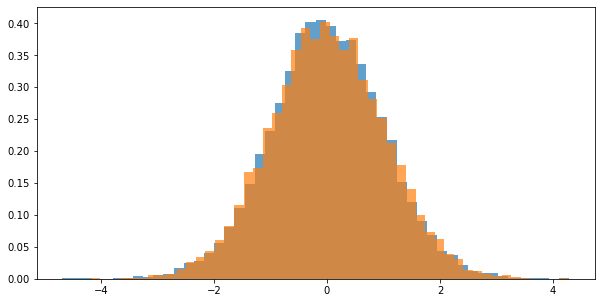

In [6]:
plt.figure(figsize=(10,5))
plt.hist(X,density=True,bins=50,alpha=0.7);
X2=np.random.normal(0, 1, size=9000);
plt.hist(X2,density=True,bins=50,alpha=0.7);

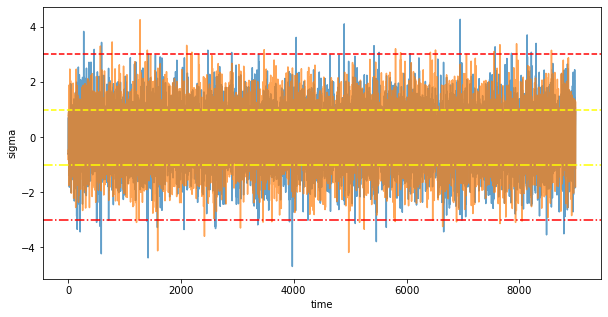

In [7]:
both = np.matrix([X, X2])

# Plot both the GARCH and normal values
plt.figure(figsize=(10,5))
plt.plot(both.T, alpha=0.7);
plt.axhline(X2.std(), color='yellow', linestyle='--')
plt.axhline(-X2.std(), color='yellow', linestyle='-.')
plt.axhline(3*X2.std(), color='red', linestyle='--')
plt.axhline(-3*X2.std(), color='red', linestyle='-.')
plt.xlabel('time')
plt.ylabel('sigma');

Nous examinons ici le processus GARCH en bleu et le processus normal en orangé.
Nous pouvons constater que le processus GARCH bleu a tendance à franchir la barre (3 $\times$ écart type ) beaucoup plus souvent que la loi normale.

## Tester un comportement ARCH

La première étape consiste à tester les conditions ARCH. Pour ce faire, nous effectuons une régression sur $ x_t $ correspondant au modèle suivant.

$$x_t^2 = a_0 + a_1 x_{t-1}^2 + \dots + a_p x_{t-p}^2$$

On utilisera OLS pour estimer  $\hat\theta = (\hat a_0, \hat a_1, \dots, \hat a_p)$ et la matrice de covariance $\hat\Omega$. On peut après calculer le test statistique 

$$F = \hat\theta \hat\Omega^{-1} \hat\theta'$$

On rejettera si $F$ est plus grand que la valeur correspendant à 95% de confiance dans ${\chi}^2_p$ distribution. On fixe $p=20$.

In [8]:
X, _ = simulate_GARCH(1100, a0, a1, b1, sigma1)
X = X[100:] # Drop burn in

p = 20

# Drop the first 20 so we have a lag of p's
Y2 = (X**2)[p:]
X2 = np.ndarray((980, p))
for i in range(p, 1000):
    X2[i - p, :] = np.asarray((X**2)[i-p:i])[::-1]

#pour i=p on a X2[0, :] = np.asarray((X**2)[0:p])[::-1]
#pour i=p+1 on a X2[1, :] = np.asarray((X**2)[1:p+1])[::-1]
#...
#pour i=999 on a X2[979, :] = np.asarray((X**2)[979: 989])[::-1]

model = sm.OLS(Y2, X2)
model = model.fit()
theta = np.matrix(model.params)
omega = np.matrix(model.cov_HC0)

#When HC0_se or cov_HC0 is called the Regression Results instance will
#        then have another attribute `het_scale`, which is in this case is just
#        resid**2.

F = (theta * np.linalg.inv(omega) * theta.T).item()

print(np.asarray(theta.T).shape)
print(np.asarray(theta))

print('F = ' + str(F))

chi2dist = scipy.stats.chi2(p)
pvalue = 1-chi2dist.cdf(F)  # = P( Xi2(p) > F )
print('p-value = ' + str(pvalue))


(20, 1)
[[ 0.20124687  0.08189991  0.0454864   0.12848647  0.11887871 -0.01770479
   0.06840945  0.01349017  0.03651333  0.06236285 -0.02541842  0.00861045
   0.03856454 -0.06048824  0.02203785 -0.00391737  0.01376191  0.05312621
   0.1038852   0.00031057]]
F = 374.25357314902294
p-value = 0.0


Clairement notre série temporelle ne suit pas un modèle ARCH

## Calibrer un modèle GARCH(1, 1) avec EMV
Une fois que nous avons décidé que les données pourraient avoir un modèle GARCH (1, 1) sous-jacent, nous aimerions calibrer le modèle GARCH (1, 1) aux données en estimant ses paramètres.

Pour ce faire, nous avons besoin de la fonction log-vraisemblance

$$\mathcal{L}(\theta) = \sum_{t=1}^T - \ln \sqrt{2\pi} - \frac{x_t^2}{2\sigma_t^2} - \frac{1}{2}\ln(\sigma_t^2)$$


Pour évaluer cette fonction, nous avons besoin de $x_t$ et ${\sigma}_t$ pour $1\le t \le T$. Nous avons 
$ x_t $, mais nous devons calculer ${\sigma}_t$. Pour faire cela, nous devons trouver une valeur pour 
${\sigma}_1$. Notre hypothèse sera $\sigma_1^2 = \hat E [x_t^2]$. Une fois que nous avons notre condition initiale, nous calculons le reste des $\sigma$ en utilisant l'équation


$$\sigma_t^2 = a_0 + a_1 x_{t-1}^2 + b_1\sigma_{t-1}^2$$

In [14]:
np.random.seed(777)
X, _ = simulate_GARCH(100000, a0, a1, b1, sigma1)
X = X[1000:] # burn in

In [15]:
# Here's our function to compute the sigmas given the initial guess
def compute_squared_sigmas(X, initial_sigma, theta):
    
    a0 = theta[0]
    a1 = theta[1]
    b1 = theta[2]
    
    T = len(X)
    sigma2 = np.ndarray(T)
    
    sigma2[0] = initial_sigma ** 2
    
    for t in range(1, T):
        # Here's where we apply the equation
        sigma2[t] = a0 + a1 * X[t-1]**2 + b1 * sigma2[t-1]
    
    return sigma2

Regardons les sigmas que nous venons de simuler.

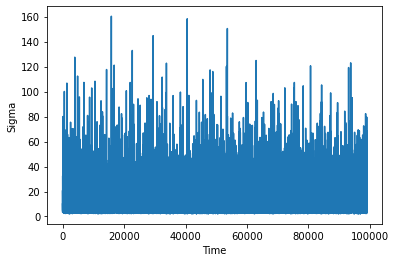

In [16]:
plt.plot(range(len(X)), compute_squared_sigmas(X, np.sqrt(np.mean(X**2)), (1, 0.5, 0.5)))
plt.xlabel('Time')
plt.ylabel('Sigma');

Maintenant que nous pouvons calculer les $\sigma_t$, nous allons définir la fonction de vraisemblance. Cette fonction prendra en entrée nos observations $x$ et $\theta$ et retournera $-\mathcal {L}(\theta)$.

Notez que nous re-calculons constamment les $\sigma_t$ dans cette fonction.

In [18]:
def negative_log_likelihood(X, theta):
    
    T = len(X)
    
    # Estimate initial sigma squared
    initial_sigma = np.sqrt(np.mean(X ** 2))
    
    # Generate the squared sigma values
    sigma2 = compute_squared_sigmas(X, initial_sigma, theta)
    
    # Now actually compute
    return -sum( [-np.log(np.sqrt(2.0 * np.pi)) -(X[t] ** 2) / (2.0 * sigma2[t]) -0.5 * np.log(sigma2[t]) for t in range(T)] )

Maintenant on optimise numériquement 
$$\hat\theta = \arg \max_{(a_0, a_1, b_1)}\mathcal{L}(\theta) = \arg \min_{(a_0, a_1, b_1)}-\mathcal{L}(\theta)$$

Sous les contraintes

$$a_1 \geq 0, b_1 \geq 0, a_1+b_1 < 1$$

In [19]:
# Make our objective function by plugging X into our log likelihood function
objective = partial(negative_log_likelihood, X)

# Define the constraints for our minimizer
def constraint1(theta):
    return np.array([1 - (theta[1] + theta[2])])

def constraint2(theta):
    return np.array([theta[1]])

def constraint3(theta):
    return np.array([theta[2]])

def constraint4(theta):
    return np.array([theta[0]])


cons = ({'type': 'ineq', 'fun': constraint1},
        {'type': 'ineq', 'fun': constraint2},
        {'type': 'ineq', 'fun': constraint3},
        {'type': 'ineq', 'fun': constraint4})

# contrainte >=0 

# Actually do the minimization
result = scipy.optimize.minimize(objective, (1, 0.5, 0.5),
                        method='SLSQP',
                        constraints = cons)
theta_mle = result.x
print('theta MLE: ' + str(theta_mle))

<ipython-input-15-e2177b572965>:15: RuntimeWarning: overflow encountered in double_scalars
  sigma2[t] = a0 + a1 * X[t-1]**2 + b1 * sigma2[t-1]
<ipython-input-18-9b3f55bc41cd>:12: RuntimeWarning: overflow encountered in double_scalars
  return -sum( [-np.log(np.sqrt(2.0 * np.pi)) -(X[t] ** 2) / (2.0 * sigma2[t]) -0.5 * np.log(sigma2[t]) for t in range(T)] )


theta MLE: [1.06178852 0.10011891 0.79378759]


Maintenant, nous voudrions un moyen de vérifier notre estimation. Nous allons regarder deux choses:

1. Quelle est la taille des queues de distribution ?
2. Faire le test de normalité de  Jarque-Bera.


In [20]:
def check_theta_estimate(X, theta_estimate):
    initial_sigma = np.sqrt(np.mean(X ** 2))
    sigma = np.sqrt(compute_squared_sigmas(X, initial_sigma, theta_estimate))
    epsilon = X / sigma
    print('Tails table')
    print(compare_tails_to_normal(epsilon / np.std(epsilon)))
    print('')
    
    _, pvalue, _, _ = jarque_bera(epsilon)
    print('Jarque-Bera probability normal: ' + str(pvalue))
    
check_theta_estimate(X, theta_mle)

Tails table
[[1.58363636e-01 2.32626263e-02 1.53535354e-03 5.05050505e-05]
 [1.58655254e-01 2.27501319e-02 1.34989803e-03 3.16712418e-05]]

Jarque-Bera probability normal: 0.12218095221519704


## GMM pour estimer les paramètres du modèle GARCH(1, 1) 


Réference méthode GMM https://swopec.hhs.se/hastef/papers/hastef0434.pdf

Pour cela, on a besoin de 

1. Le résidu $\hat\epsilon_t = x_t / \hat\sigma_t$
2. La variance du résidu $\hat\epsilon_t^2$
3. Le skew  $\mu_3/\hat\sigma_t^3 = (\hat\epsilon_t - E[\hat\epsilon_t])^3 / \hat\sigma_t^3$
4. Le kurtosis  $\mu_4/\hat\sigma_t^4 = (\hat\epsilon_t - E[\hat\epsilon_t])^4 / \hat\sigma_t^4$

In [22]:
# The n-th standardized moment
# skewness is 3, kurtosis is 4
def standardized_moment(x, mu, sigma, n):
    return ((x - mu) ** n) / (sigma ** n)

MMG se fait en trois étapes:

Commencer par $W$ comme une matrice identité.

1. Estimer $\hat\theta_1$ en minimisant numériquement

$$\min_{\theta \in \Theta} \left(\frac{1}{T} \sum_{t=1}^T g(x_t, \hat\theta)\right)' W \left(\frac{1}{T}\sum_{t=1}^T g(x_t, \hat\theta)\right)$$

2. Recalculer $W$ en se basant sur les  covariances du $\theta$ estimé. 
$$\hat W_{i+1} = \left(\frac{1}{T}\sum_{t=1}^T g(x_t, \hat\theta_i)g(x_t, \hat\theta_i)'\right)^{-1}$$

3. Répéter jusqu'à ce que  $|\hat\theta_{i+1} - \hat\theta_i| < \epsilon$ ou on atteint un seuil fixé.

Initialiser $W$ et $T$ et définir la fonction objectif qu'on doit minimiser.

In [23]:
def gmm_objective(X, W, theta):
    # Compute the residuals for X and theta
    initial_sigma = np.sqrt(np.mean(X ** 2))
    sigma = np.sqrt(compute_squared_sigmas(X, initial_sigma, theta))
    e = X / sigma # bruit blanc epsilon
    
    # Compute the mean moments
    m1 = np.mean(e)
    m2 = np.mean(e ** 2) - 1
    m3 = np.mean(standardized_moment(e, np.mean(e), np.std(e), 3))
    m4 = np.mean(standardized_moment(e, np.mean(e), np.std(e), 4) - 3) # 3 désigne la kurtosis de la gaussienne
    
    G = np.matrix([m1, m2, m3, m4]).T
    
    return (G.T * W * G).item()

def gmm_variance(X, theta):
    # Compute the residuals for X and theta    
    initial_sigma = np.sqrt(np.mean(X ** 2))
    sigma = np.sqrt(compute_squared_sigmas(X, initial_sigma, theta))
    e = X / sigma

    # Compute the squared moments
    m1 = e ** 2
    m2 = (e ** 2 - 1) ** 2
    m3 = standardized_moment(e, np.mean(e), np.std(e), 3) ** 2
    m4 = (standardized_moment(e, np.mean(e), np.std(e), 4) - 3) ** 2
    
    # Compute the covariance matrix g * g'
    T = len(X)
    s = np.ndarray((4, 1))
    for t in range(T):
        G = np.matrix([m1[t], m2[t], m3[t], m4[t]]).T
        s = s + G * G.T
    
    return s / T

Minimisation par itération

In [27]:
# Initialize GMM parameters
W = np.identity(4)
gmm_iterations = 10

# First guess
theta_gmm_estimate = theta_mle

# Perform iterated GMM
for i in range(gmm_iterations):
    # Estimate new theta
    objective = partial(gmm_objective, X, W)
    result = scipy.optimize.minimize(objective, theta_gmm_estimate, constraints=cons)
    theta_gmm_estimate = result.x
    print('Iteration ' + str(i) + ' theta: ' + str(theta_gmm_estimate))
    
    # Recompute W
    W = np.linalg.inv(gmm_variance(X, theta_gmm_estimate))
    

check_theta_estimate(X, theta_gmm_estimate)

Iteration 0 theta: [1.061789   0.10010964 0.79377823]
Iteration 1 theta: [1.06177589 0.0999988  0.79365366]
Iteration 2 theta: [1.06177845 0.10002041 0.79367795]
Iteration 3 theta: [1.06177845 0.10002041 0.79367795]
Iteration 4 theta: [1.06177845 0.10002041 0.79367795]
Iteration 5 theta: [1.06177845 0.10002041 0.79367795]
Iteration 6 theta: [1.06177845 0.10002041 0.79367795]
Iteration 7 theta: [1.06177845 0.10002041 0.79367795]
Iteration 8 theta: [1.06177845 0.10002041 0.79367795]
Iteration 9 theta: [1.06177845 0.10002041 0.79367795]
Tails table
[[1.58353535e-01 2.32323232e-02 1.53535354e-03 5.05050505e-05]
 [1.58655254e-01 2.27501319e-02 1.34989803e-03 3.16712418e-05]]

Jarque-Bera probability normal: 0.12223152993640275


## Prédire le future
Maintenant que nous avons calibré le modèle à nos observations, nous aimerions pouvoir prédire à quoi ressemblera la volatilité future. Pour ce faire, nous pouvons simplement simuler plus de valeurs en utilisant notre dynamique GARCH originale et les paramètres estimés.


In [25]:
sigma_hats = np.sqrt(compute_squared_sigmas(X, np.sqrt(np.mean(X**2)), theta_mle))
initial_sigma = sigma_hats[-1]
initial_sigma

3.1161110916310326

Simuler des valeurs futures

In [28]:
a0_estimate = theta_mle[0]
a1_estimate = theta_mle[1]
b1_estimate = theta_mle[2]

X_forecast, sigma_forecast = simulate_GARCH(100, a0_estimate, a1_estimate, b1_estimate, initial_sigma)

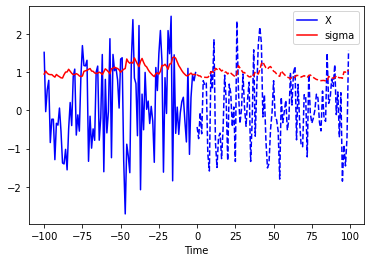

In [30]:
plt.plot(range(-100, 0), X[-100:], 'b-')
plt.plot(range(-100, 0), sigma_hats[-100:], 'r-')
plt.plot(range(0, 100), X_forecast, 'b--')
plt.plot(range(0, 100), sigma_forecast, 'r--')
plt.xlabel('Time')
plt.legend(['X', 'sigma']);

En pratique, on voudrait probablement générer des milliers de scénarios futurs, puis examiner la plage potentielle de sorties (risque de hausse de volatilité)


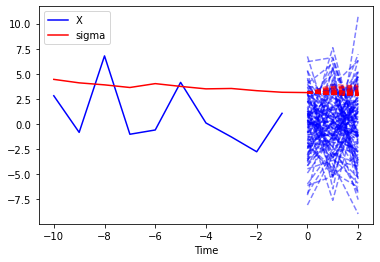

In [56]:
M=100 # taille des simulations de prédiction 
N=3 # nombre des prochaines dates à prédire
plt.plot(range(-10, 0), X[-10:], 'b-')
plt.plot(range(-10, 1), sigma_hats[-11:], 'r-')
plt.xlabel('Time')
plt.legend(['X', 'sigma'])


max_X = [-np.inf]
min_X = [np.inf]
for i in range(M):
    X_forecast, sigma_forecast = simulate_GARCH(N, a0_estimate, a1_estimate, b1_estimate, initial_sigma)
    if max(X_forecast) > max(max_X):
        max_X = X_forecast
    elif min(X_forecast) < min(max_X):
        min_X = X_forecast
    plt.plot(range(0, N), X_forecast, 'b--', alpha=0.5)
    plt.plot(range(0, N), sigma_forecast, 'r--', alpha=0.5)

#Draw the most extreme X values specially
#plt.plot(range(0, N), max_X, 'g--', alpha=1.0)
#plt.plot(range(0, N), min_X, 'g--', alpha=1.0);
# réduire le nombre de dates futures à prédire